## Loading Libraries

In [ ]:
from pandas import read_csv
import time
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif

In [2]:
from google.colab import files
import pandas as pd
import io

# 1. Trigger the upload prompt
uploaded = files.upload()

# 2. Read the file into a Pandas DataFrame (replace 'your_file.csv' with your actual filename)
df = pd.read_csv(io.BytesIO(uploaded['iris.csv']))
df.head()


Saving iris.csv to iris.csv


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## Splitting datasets into train and test

In [3]:
# Load dataset
dataset = pd.read_csv("iris.csv")
array = dataset.values
X = array[:, 0:4]
y = array[:, 4]

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

## 1) Naive Bayes Algorithm

In [4]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.naive_bayes import GaussianNB
import pandas as pd

# prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# create model
model_NB = GaussianNB()

# evaluate model
scores1 = cross_val_score(model_NB, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_NB, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_NB, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_NB, X_train, y_train, scoring='f1_macro', cv=cv)

# report performance
print('Accuracy: %.3f (%.3f)' % (scores1.mean(), scores1.std()))
print('Precision: %.3f (%.3f)' % (scores2.mean(), scores2.std()))
print('Recall: %.3f (%.3f)' % (scores3.mean(), scores3.std()))
print('F1-score: %.3f (%.3f)' % (scores4.mean(), scores4.std()))

Accuracy: 0.950 (0.041)
Precision: 0.949 (0.045)
Recall: 0.957 (0.038)
F1-score: 0.946 (0.045)


## 2) k-Nearest-Neighbors Algorithm (kNN)

In [5]:
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score
from sklearn.neighbors import KNeighborsClassifier

# Create model
model_KNN = KNeighborsClassifier(n_neighbors=3)

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# Evaluate model using cross-validation
scores1 = cross_val_score(model_KNN, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_KNN, X_train, y_train, scoring='precision_weighted', cv=cv)
scores3 = cross_val_score(model_KNN, X_train, y_train, scoring='recall_weighted', cv=cv)
scores4 = cross_val_score(model_KNN, X_train, y_train, scoring='f1_weighted', cv=cv)

# Report performance
print('Accuracy: %.3f (%.3f)' % (scores1.mean(), scores1.std()))
print('Precision: %.3f (%.3f)' % (scores2.mean(), scores2.std()))
print('Recall: %.3f (%.3f)' % (scores3.mean(), scores3.std()))
print('F1-score: %.3f (%.3f)' % (scores4.mean(), scores4.std()))

Accuracy: 0.950 (0.041)
Precision: 0.962 (0.031)
Recall: 0.950 (0.041)
F1-score: 0.951 (0.040)


## 3) Decision Trees Algorithms

In [6]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from numpy import mean, std

# Create model
model_DT = DecisionTreeClassifier()

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# Evaluate model
scores1 = cross_val_score(model_DT, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_DT, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_DT, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_DT, X_train, y_train, scoring='f1_macro', cv=cv)

# Report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores1), std(scores1)))
print('Precision: %.3f (%.3f)' % (mean(scores2), std(scores2)))
print('Recall: %.3f (%.3f)' % (mean(scores3), std(scores3)))
print('F1-score: %.3f (%.3f)' % (mean(scores4), std(scores4)))

Accuracy: 0.958 (0.042)
Precision: 0.953 (0.050)
Recall: 0.961 (0.044)
F1-score: 0.949 (0.042)


## 4) Support Vector Machine Algorithm (SVM)

In [7]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.svm import SVC
import pandas as pd
from numpy import mean, std

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# Create model
model_SVM = SVC()

# Evaluate model
scores1 = cross_val_score(model_SVM, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_SVM, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_SVM, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_SVM, X_train, y_train, scoring='f1_macro', cv=cv)

# Report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores1), std(scores1)))
print('Precision: %.3f (%.3f)' % (mean(scores2), std(scores2)))
print('Recall: %.3f (%.3f)' % (mean(scores3), std(scores3)))
print('F1-score: %.3f (%.3f)' % (mean(scores4), std(scores4)))

Accuracy: 0.967 (0.041)
Precision: 0.970 (0.039)
Recall: 0.968 (0.041)
F1-score: 0.965 (0.044)


## 5) Random Forest

In [8]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from numpy import mean, std

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# Create model
model_RF = RandomForestClassifier()

# Evaluate model
scores1 = cross_val_score(model_RF, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_RF, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_RF, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_RF, X_train, y_train, scoring='f1_macro', cv=cv)

# Report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores1), std(scores1)))
print('Precision: %.3f (%.3f)' % (mean(scores2), std(scores2)))
print('Recall: %.3f (%.3f)' % (mean(scores3), std(scores3)))
print('F1-score: %.3f (%.3f)' % (mean(scores4), std(scores4)))

Accuracy: 0.950 (0.055)
Precision: 0.957 (0.046)
Recall: 0.951 (0.047)
F1-score: 0.958 (0.043)


## Compare Algorithms

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

LR: 0.941667 (0.065085)
LDA: 0.975000 (0.038188)
KNN: 0.958333 (0.041667)
CART: 0.950000 (0.040825)
NB: 0.950000 (0.055277)
SVM: 0.983333 (0.033333)


/tmp/ipykernel_2442/3520151816.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names)


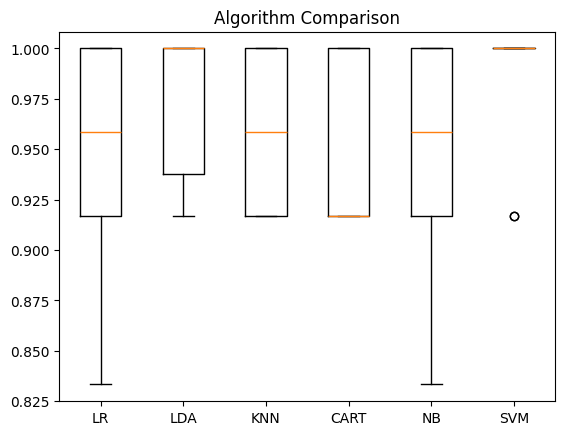

In [9]:
# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))
# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

#Select Best Model
#=================================
# Compare Algorithms
plt.boxplot(results, labels=names)
plt.title('Algorithm Comparison')
plt.show()